In [1]:
# Este comando descarga el repositorio entero a una carpeta llamada 'TFMDS' en Colab.
#!git clone https://github.com/jmorala/TFMDS.git

# Inicializar directorios
Clonar repositorio github
Posicionarse en el directorio raíz

In [2]:
import os

# Detectar si estamos en Google Colab
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Configurar el directorio de trabajo según el entorno
if IN_COLAB:
    os.chdir('TFMDS')
else:
    # Detectar si estamos en Codespaces o VS Code local
    if os.path.exists('/workspaces/TFMDS'):
        # Entorno Codespaces
        os.chdir('/workspaces/TFMDS')
    else:
        # En VS Code local, nos movemos al directorio raíz del proyecto
        # Usa raw string para evitar errores de escape en rutas Windows
        current_dir = r'C:\Users\jmora\Documents\TFMDS'
        os.chdir(current_dir)

# OPCIONAL: Para verificar que estás en la ruta correcta y ver las carpetas
print("Directorio de trabajo actual:", os.getcwd())

Directorio de trabajo actual: C:\Users\jmora\Documents\TFMDS


In [3]:
import pandas as pd
import numpy as np
import optuna
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
import warnings
import time
warnings.filterwarnings('ignore')

# Importar funciones personalizadas
from lib.metricas import calcular_metricas, comparar_metricas, resumen_metricas, agregar_estadisticas_error
from lib.graficos import (grafico_real_vs_prediccion, grafico_scatter_prediccion, grafico_comparacion_metricas,
                          grafico_distribucion_error, grafico_feature_importance, dashboard_prediccion)

## Lectura de fichero y adaptación de los tipos


In [4]:
df_train = pd.read_csv('datos/df_train.csv', sep=';', parse_dates=['idSecuencia'])
df_test = pd.read_csv('datos/df_test.csv', sep=';', parse_dates=['idSecuencia'])

print("\nInformación de las columnas y tipos de datos:")
print(df_train.info())
print(df_test.info())


Información de las columnas y tipos de datos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 625800 entries, 0 to 625799
Data columns (total 25 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   idSecuencia         625800 non-null  datetime64[ns]
 1   producto            625800 non-null  int64         
 2   udsVenta            625800 non-null  int64         
 3   bolPromocion        625800 non-null  int64         
 4   bolOpen             625800 non-null  int64         
 5   bolHoliday          625800 non-null  int64         
 6   udsStock            625800 non-null  int64         
 7   rotura_stock        625800 non-null  bool          
 8   dia_semana          625800 non-null  int64         
 9   mes                 625800 non-null  int64         
 10  trimestre           625800 non-null  int64         
 11  semana              625800 non-null  int64         
 12  lag_ventas_1        625800 non-null  fl

# Random Forests (RF)

El algoritmo **Random Forest** (RF) es un método de **aprendizaje de conjunto (ensemble)** que construye y combina resultados de múltiples árboles de decisión.

1. **Generación de Múltiples Árboles (Bagging):** Cada árbol se entrena sobre un subconjunto de datos diferente utilizando la técnica de **Bagging** (Bootstrap Aggregating). Esto implica tomar **muestras repetidas con reemplazo** del conjunto de entrenamiento original (muestreo *bootstrap*).

2. **Decorrelación (Aleatoriedad de Características):** Para garantizar que los árboles no estén correlacionados (sean *decorrelacionados*), en cada paso de división (*split*) del árbol, el algoritmo considera solo un **subconjunto aleatorio de las características** disponibles para encontrar la mejor división. Esta doble aleatoriedad (en datos y en características) ayuda a reducir la **varianza**.

3. **Obtención del Resultado Final:** Una vez entrenados todos los árboles del "bosque" ($M$ árboles), el resultado final se obtiene:
    *   Para problemas de **Regresión** (predicción de series temporales), se obtiene **promediando** las salidas de todos los árboles.
    *   Para problemas de **Clasificación**, se obtiene por **votación mayoritaria**.

Este método es popular ya que es difícil que sufra de sobreajuste (*overfitting*) y aumenta la solidez de la predicción.




# Preparación de datos

In [5]:
# Eliminar días que la tienda está cerrada bolOpne == 0 ya que en modelos tipo Random Forest no aportan nada
df_train = df_train[df_train['bolOpen'] == 1].copy()
df_test = df_test[df_test['bolOpen'] == 1].copy()

In [6]:
# ============================================================================
# CONFIGURACIÓN INICIAL
# ============================================================================

FEATURES = [
    'producto_encoded', 'bolPromocion', 'bolHoliday', 'Cluster',
    'dia_semana', 'mes', 'semana',
    'lag_ventas_1', 'lag_ventas_2', 'lag_ventas_3', 'lag_ventas_4',
    'lag_ventas_5', 'lag_ventas_6', 'lag_ventas_7',
    'media_mes_anterior', 'EWMA_corto', 'EWMA_largo', 'Tendencia_EWMA'
]

TARGET = 'udsVenta'

# ============================================================================
# LISTA PARA ALMACENAR TODAS LAS MÉTRICAS
# ============================================================================
todas_metricas = []  # ← Lista global para todas las métricas

print("="*100)
print("🚀 INICIANDO ANÁLISIS COMPLETO DE RANDOM FOREST")
print("="*100)


🚀 INICIANDO ANÁLISIS COMPLETO DE RANDOM FOREST


# Random Forest global
modelo sobre todas la fechas y productos
Se va utilizar Optuna para buscar los mejores hiperparámetros.
Estos parámetros se utilizarán en los próximos modelos de Random Forest para cluster y productos, se asume que posiblemente serán los mismos parámetros, no se palntea utilizar optuna en el resto de modelos por el coste de tiempo que lleva

In [7]:
# ============================================================================
# 1. MODELO GLOBAL CON OPTUNA
# ============================================================================

print("\n" + "="*100)
print("📍 MODELO 1: RANDOM FOREST GLOBAL")
print("="*100)

# Preparar datos
X_train = df_train[FEATURES]
y_train = df_train[TARGET]
X_test = df_test[FEATURES]
y_test = df_test[TARGET]

print(f"\n✅ X_train shape: {X_train.shape}")
print(f"✅ X_test shape: {X_test.shape}")

# Último 20% como validación temporal
VAL_SIZE = int(len(X_train) * 0.2)

X_tr = X_train.iloc[:-VAL_SIZE]
y_tr = y_train.iloc[:-VAL_SIZE]

X_val = X_train.iloc[-VAL_SIZE:]
y_val = y_train.iloc[-VAL_SIZE:]

print(f"\n✅ X_tr shape: {X_tr.shape}")
print(f"✅ X_val shape: {X_val.shape}")
print(f"✅ y_tr shape: {y_tr.shape}")
print(f"✅ y_val shape: {y_val.shape}")



📍 MODELO 1: RANDOM FOREST GLOBAL

✅ X_train shape: (521202, 18)
✅ X_test shape: (23244, 18)

✅ X_tr shape: (416962, 18)
✅ X_val shape: (104240, 18)
✅ y_tr shape: (416962,)
✅ y_val shape: (104240,)

✅ X_train shape: (521202, 18)
✅ X_test shape: (23244, 18)

✅ X_tr shape: (416962, 18)
✅ X_val shape: (104240, 18)
✅ y_tr shape: (416962,)
✅ y_val shape: (104240,)


In [8]:
print("\n🔍 Búsqueda de hiperparámetros con Optuna...")

# =====================================================
#  FUNCION OBJETIVO OPTUNA PARA RANDOM FOREST
# =====================================================

def objective_rf(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1000),
        "max_depth": trial.suggest_int("max_depth", 4, 25),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2"]),
        "bootstrap": trial.suggest_categorical("bootstrap", [True, False]),
        "random_state": 42,
        "n_jobs": -1
    }

    model = RandomForestRegressor(**params)

    model.fit(X_tr, y_tr)
    preds = model.predict(X_val)

    mse = mean_squared_error(y_val, preds)
    return mse

tscv = TimeSeriesSplit(n_splits=2)

# =====================================================
# EJECUTAR OPTUNA
# =====================================================
print("\n🔍 Iniciando optimización de hiperparámetros con Optuna para Random Forest...")
start_time = time.perf_counter()

study_rf = optuna.create_study(direction="minimize")
study_rf.optimize(objective_rf, n_trials=5, n_jobs=-1)

elapsed = time.perf_counter() - start_time
print(f"✅ Optuna completado en {elapsed:.2f} segundos")

print("\n🌲 Mejores hiperparámetros RANDOM FOREST:")
print(study_rf.best_params)


[I 2025-12-01 13:32:42,582] A new study created in memory with name: no-name-f777e971-c75f-4499-9d14-cd0ec633c4d2



🔍 Búsqueda de hiperparámetros con Optuna...

🔍 Iniciando optimización de hiperparámetros con Optuna para Random Forest...


[I 2025-12-01 13:36:16,530] Trial 1 finished with value: 3.8247181931217837 and parameters: {'n_estimators': 207, 'max_depth': 13, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_features': 'log2', 'bootstrap': True}. Best is trial 1 with value: 3.8247181931217837.
[I 2025-12-01 13:41:02,400] Trial 4 finished with value: 3.7956450147082843 and parameters: {'n_estimators': 299, 'max_depth': 19, 'min_samples_split': 2, 'min_samples_leaf': 7, 'max_features': 'log2', 'bootstrap': False}. Best is trial 4 with value: 3.7956450147082843.
[I 2025-12-01 13:41:02,400] Trial 4 finished with value: 3.7956450147082843 and parameters: {'n_estimators': 299, 'max_depth': 19, 'min_samples_split': 2, 'min_samples_leaf': 7, 'max_features': 'log2', 'bootstrap': False}. Best is trial 4 with value: 3.7956450147082843.
[I 2025-12-01 13:41:29,368] Trial 3 finished with value: 3.83644918506293 and parameters: {'n_estimators': 500, 'max_depth': 11, 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_featur

✅ Optuna completado en 590.86 segundos

🌲 Mejores hiperparámetros RANDOM FOREST:
{'n_estimators': 299, 'max_depth': 19, 'min_samples_split': 2, 'min_samples_leaf': 7, 'max_features': 'log2', 'bootstrap': False}


In [9]:
print("\nEntrenando modelo RANDOM FOREST con mejores hiperparámetros en todo el conjunto de entrenamiento...")
best_rf = RandomForestRegressor(
    **study_rf.best_params,
    random_state=42,
    n_jobs=-1
)
best_rf.fit(X_train, y_train)


Entrenando modelo RANDOM FOREST con mejores hiperparámetros en todo el conjunto de entrenamiento...


,n_estimators,299
,criterion,'squared_error'
,max_depth,19
,min_samples_split,2
,min_samples_leaf,7
,min_weight_fraction_leaf,0.0
,max_features,'log2'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


In [10]:
from lib.utils import obtener_top_productos_por_cluster

# Predicciones
y_test_pred = best_rf.predict(X_test)

# Calcular métricas y GUARDAR
metricas_test_global = calcular_metricas(y_test, y_test_pred, 'RF Global')

# todas_metricas.append(metricas_train_global)
todas_metricas.append(metricas_test_global)

print("\n📊 Métricas del Modelo Global:")
resumen_metricas([metricas_test_global])

# Calcular métricas por cluster y guardar
for cluster in df_test['Cluster'].unique():
    y_test_pred_cl = y_test_pred[X_test['Cluster'] == cluster]
    y_test_cl = y_test[X_test['Cluster'] == cluster]
    metricas_cluster = calcular_metricas(y_test_cl, y_test_pred_cl, f'RF Global Cluster {cluster}')
    todas_metricas.append(metricas_cluster)
    
# Calcular métricas por producto top en cada cluster
top_productos = obtener_top_productos_por_cluster(
    df=df_train,
    col_ventas='udsVenta',
    col_cluster='Cluster',
    col_producto='producto',
    n_productos=2
)

for cluster, productos in top_productos.items():
    for producto in productos:
        idx_producto = (df_test['Cluster'] == cluster) & (df_test['producto'] == producto)
        y_test_prod = y_test[idx_producto]
        y_test_pred_prod = y_test_pred[idx_producto]
        metricas_producto = calcular_metricas(y_test_prod, y_test_pred_prod, f'RF Global Cluster {cluster} Producto {producto}')
        todas_metricas.append(metricas_producto)

resumen_metricas(todas_metricas)       


📊 Métricas del Modelo Global:

📊 RESUMEN DE MÉTRICAS
           Algoritmo    MAE    MSE  RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
           RF Global 1.5844 5.7454 2.397 0.2502     49.05     144.09 0.7346    97.04

🏆 Mejor modelo: RF Global (RMSE: 2.3970)

📊 RESUMEN DE MÉTRICAS
                       Algoritmo    MAE      MSE    RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
RF Global Cluster 3 Producto 314 0.3353   0.1239  0.3520  0.0000       NaN     200.00    NaN      NaN
RF Global Cluster 3 Producto 257 0.8588   1.3869  1.1776 -0.0452     73.80     184.80 0.8013   171.75
             RF Global Cluster 3 1.0967   2.9465  1.7165  0.0127     54.09     168.41 0.7703   135.04
RF Global Cluster 0 Producto 413 1.7258   4.6867  2.1649  0.0317     34.55     102.59 0.7579    83.10
                       RF Global 1.5844   5.7454  2.3970  0.2502     49.05     144.09 0.7346    97.04
             RF Global Cluster 0 1.8104   6.5064  2.5508  0.1161     39.51     125.41 0.7333    93.

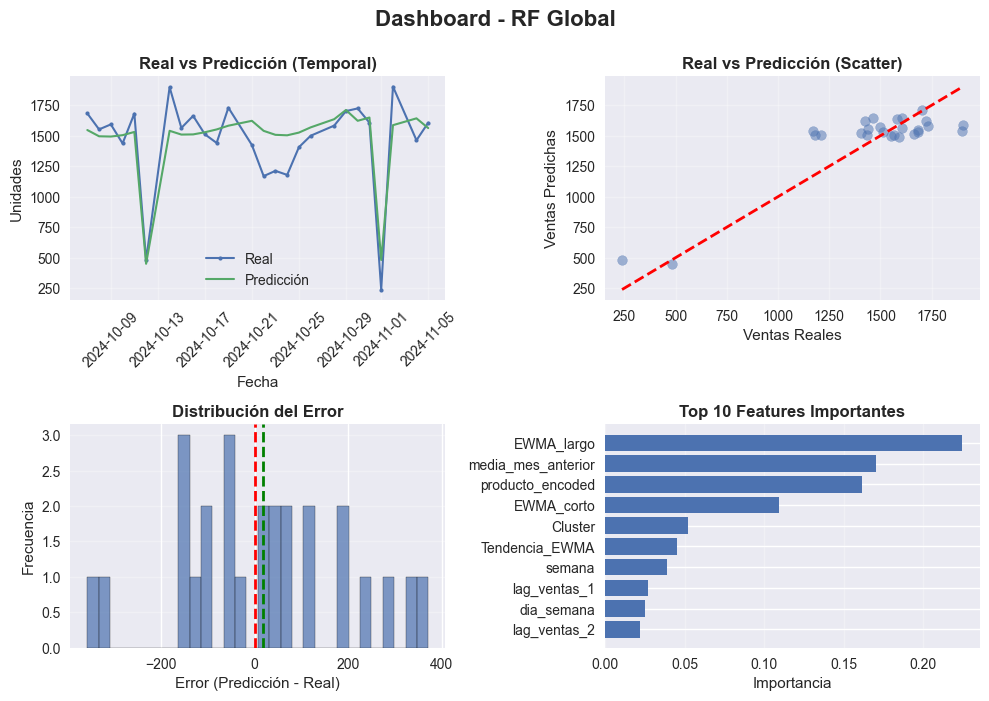

In [11]:
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8')

# Visualizaciones del modelo global
df_test_viz = df_test.copy()
df_test_viz['prediccion'] = y_test_pred
#df_test_viz['error'] = y_test_pred - df_test_viz[TARGET]
df_test_viz_sum = df_test_viz.groupby('idSecuencia')[[TARGET, 'prediccion']].sum().reset_index()
df_test_viz_sum['error'] = df_test_viz_sum['prediccion'] - df_test_viz_sum[TARGET]

dashboard_prediccion(
        df=df_test_viz_sum,
        col_fecha='idSecuencia',
        col_real=TARGET,
        col_pred='prediccion',
        modelo=best_rf,
        feature_names=FEATURES,
        titulo_principal=f'Dashboard - RF Global',
        figsize=(10, 7)
        )


# Random Forest por Cluster


📍 MODELO 2: RANDOM FOREST POR CLUSTER

🔄 Entrenando modelo para Cluster 0...

📊 RESUMEN DE MÉTRICAS
           Algoritmo    MAE    MSE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
        RF Cluster 0 1.8111 6.5276 2.5549 0.1132     39.54     125.47 0.7345    93.79

🏆 Mejor modelo: RF Cluster 0 (RMSE: 2.5549)

📊 RESUMEN DE MÉTRICAS
           Algoritmo    MAE    MSE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
        RF Cluster 0 1.8111 6.5276 2.5549 0.1132     39.54     125.47 0.7345    93.79

🏆 Mejor modelo: RF Cluster 0 (RMSE: 2.5549)


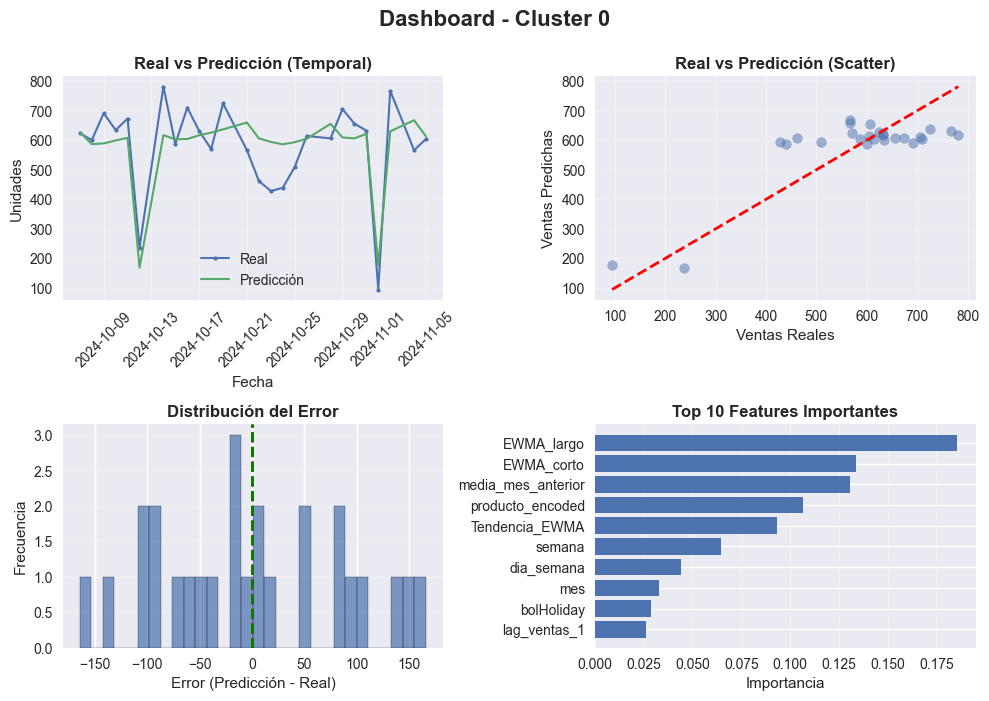


🔄 Entrenando modelo para Cluster 1...

📊 RESUMEN DE MÉTRICAS
           Algoritmo    MAE     MSE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
        RF Cluster 1 2.8115 12.9994 3.6055 0.1354     55.97      98.51 0.7206    73.73

🏆 Mejor modelo: RF Cluster 1 (RMSE: 3.6055)

📊 RESUMEN DE MÉTRICAS
           Algoritmo    MAE     MSE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
        RF Cluster 1 2.8115 12.9994 3.6055 0.1354     55.97      98.51 0.7206    73.73

🏆 Mejor modelo: RF Cluster 1 (RMSE: 3.6055)


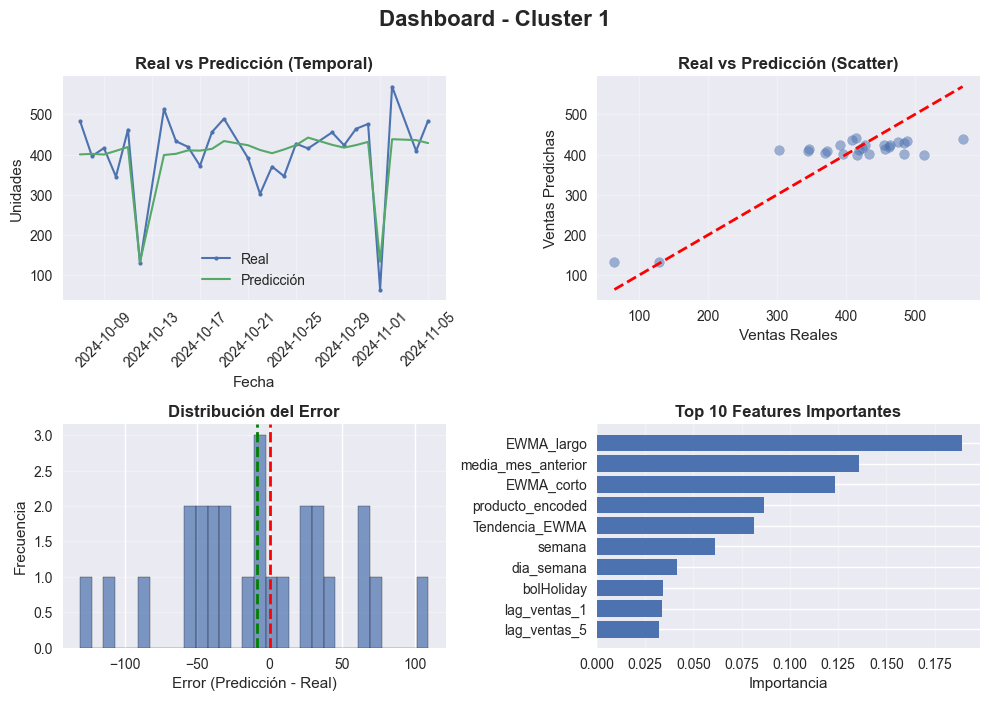


🔄 Entrenando modelo para Cluster 2...

📊 RESUMEN DE MÉTRICAS
           Algoritmo    MAE     MSE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
        RF Cluster 2 3.7804 26.8449 5.1812 0.1704     76.86      81.15 0.7205    65.83

🏆 Mejor modelo: RF Cluster 2 (RMSE: 5.1812)

📊 RESUMEN DE MÉTRICAS
           Algoritmo    MAE     MSE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
        RF Cluster 2 3.7804 26.8449 5.1812 0.1704     76.86      81.15 0.7205    65.83

🏆 Mejor modelo: RF Cluster 2 (RMSE: 5.1812)


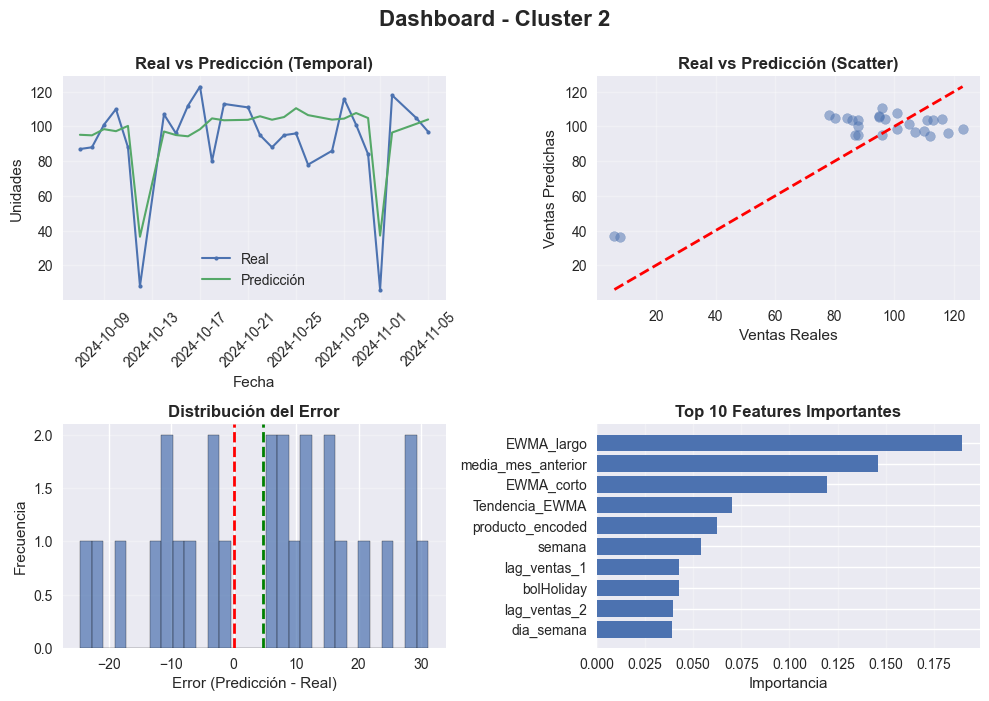


🔄 Entrenando modelo para Cluster 3...

📊 RESUMEN DE MÉTRICAS
           Algoritmo    MAE    MSE  RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
        RF Cluster 3 1.0949 2.9448 1.716 0.0133     54.26     168.51 0.7701   134.82

🏆 Mejor modelo: RF Cluster 3 (RMSE: 1.7160)

📊 RESUMEN DE MÉTRICAS
           Algoritmo    MAE    MSE  RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
        RF Cluster 3 1.0949 2.9448 1.716 0.0133     54.26     168.51 0.7701   134.82

🏆 Mejor modelo: RF Cluster 3 (RMSE: 1.7160)


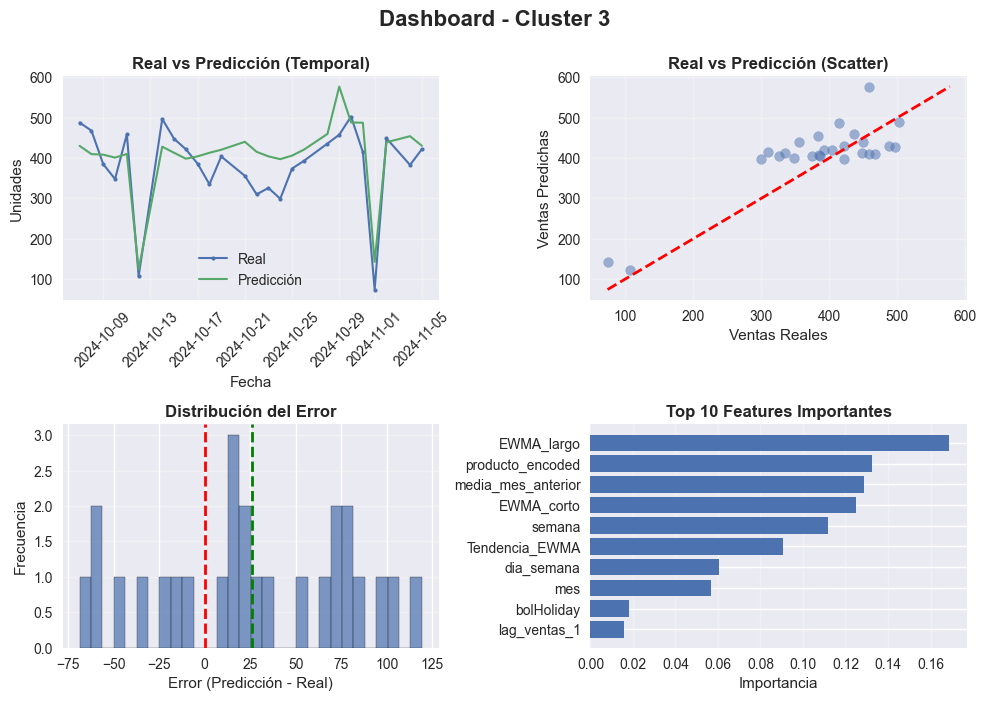

In [12]:
# ============================================================================
# 2. MODELOS POR CLUSTER
# ============================================================================

print("\n" + "="*100)
print("📍 MODELO 2: RANDOM FOREST POR CLUSTER")
print("="*100)

modelos_cluster = {}

for cluster in sorted(df_train['Cluster'].unique()):
    print(f"\n🔄 Entrenando modelo para Cluster {cluster}...")
    
    # Filtrar datos
    train_cluster = df_train[df_train['Cluster'] == cluster]
    test_cluster = df_test[df_test['Cluster'] == cluster].dropna()
    
    if len(test_cluster) == 0:
        print(f"   ⚠️  No hay datos de validación")
        continue
    
    X_train_c = train_cluster[FEATURES]
    y_train_c = train_cluster[TARGET]
    X_test_c = test_cluster[FEATURES]
    y_test_c = test_cluster[TARGET]
    
    # Entrenar
    rf_cluster = RandomForestRegressor(
        **study_rf.best_params,
        random_state=42,
        n_jobs=-1
)
    
    rf_cluster.fit(X_train_c, y_train_c)
    y_pred_c = rf_cluster.predict(X_test_c)
    
    # modelos_cluster[cluster] = rf_cluster
    
    # Calcular métricas y GUARDAR
    metricas_cluster = calcular_metricas(y_test_c, y_pred_c, f"RF Cluster {cluster}")
    todas_metricas.append(metricas_cluster)
    
    # Calcular métricas por producto top en cada cluster
    top_productos = obtener_top_productos_por_cluster(
        df=train_cluster,
        col_ventas='udsVenta',
        col_cluster='Cluster',
        col_producto='producto',
        n_productos=2
    ) 
    
    for producto in top_productos.get(cluster, []):
        idx_producto = (test_cluster['producto'] == producto)
        y_test_prod = y_test_c[idx_producto]
        y_test_pred_prod = y_pred_c[idx_producto]
        metricas_producto = calcular_metricas(y_test_prod, y_test_pred_prod, f'RF Cluster {cluster} Producto {producto}')
        todas_metricas.append(metricas_producto)
    
    resumen_metricas([metricas_cluster])
    
    # Visualizaciones del modelo cluster
    df_test_viz = test_cluster.copy()
    df_test_viz['prediccion'] = y_pred_c
    df_test_viz_sum = df_test_viz.groupby('idSecuencia')[[TARGET, 'prediccion']].sum().reset_index()
    df_test_viz_sum['error'] = df_test_viz_sum['prediccion'] - df_test_viz_sum[TARGET]
    
    dashboard_prediccion(
        df=df_test_viz_sum,
        col_fecha='idSecuencia',
        col_real=TARGET,
        col_pred='prediccion',
        modelo=rf_cluster,
        feature_names=FEATURES,
        titulo_principal=f'Dashboard - Cluster {cluster}',
        figsize=(10, 7)
        )
  


# Random Forest por top 2 productos de ventas por cluster


📍 MODELO 3: RANDOM FOREST POR PRODUCTO TOP (2 POR CLUSTER)

🎯 CLUSTER 0 - Top 2 productos

🔄 Entrenando modelo para Producto 413 (Cluster 0)...

📊 RESUMEN DE MÉTRICAS
           Algoritmo    MAE    MSE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
RF Producto 413 (C0) 1.7152 4.6184 2.1491 0.0458     33.93     103.71 0.7523    82.59

🏆 Mejor modelo: RF Producto 413 (C0) (RMSE: 2.1491)

📊 RESUMEN DE MÉTRICAS
           Algoritmo    MAE    MSE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
RF Producto 413 (C0) 1.7152 4.6184 2.1491 0.0458     33.93     103.71 0.7523    82.59

🏆 Mejor modelo: RF Producto 413 (C0) (RMSE: 2.1491)


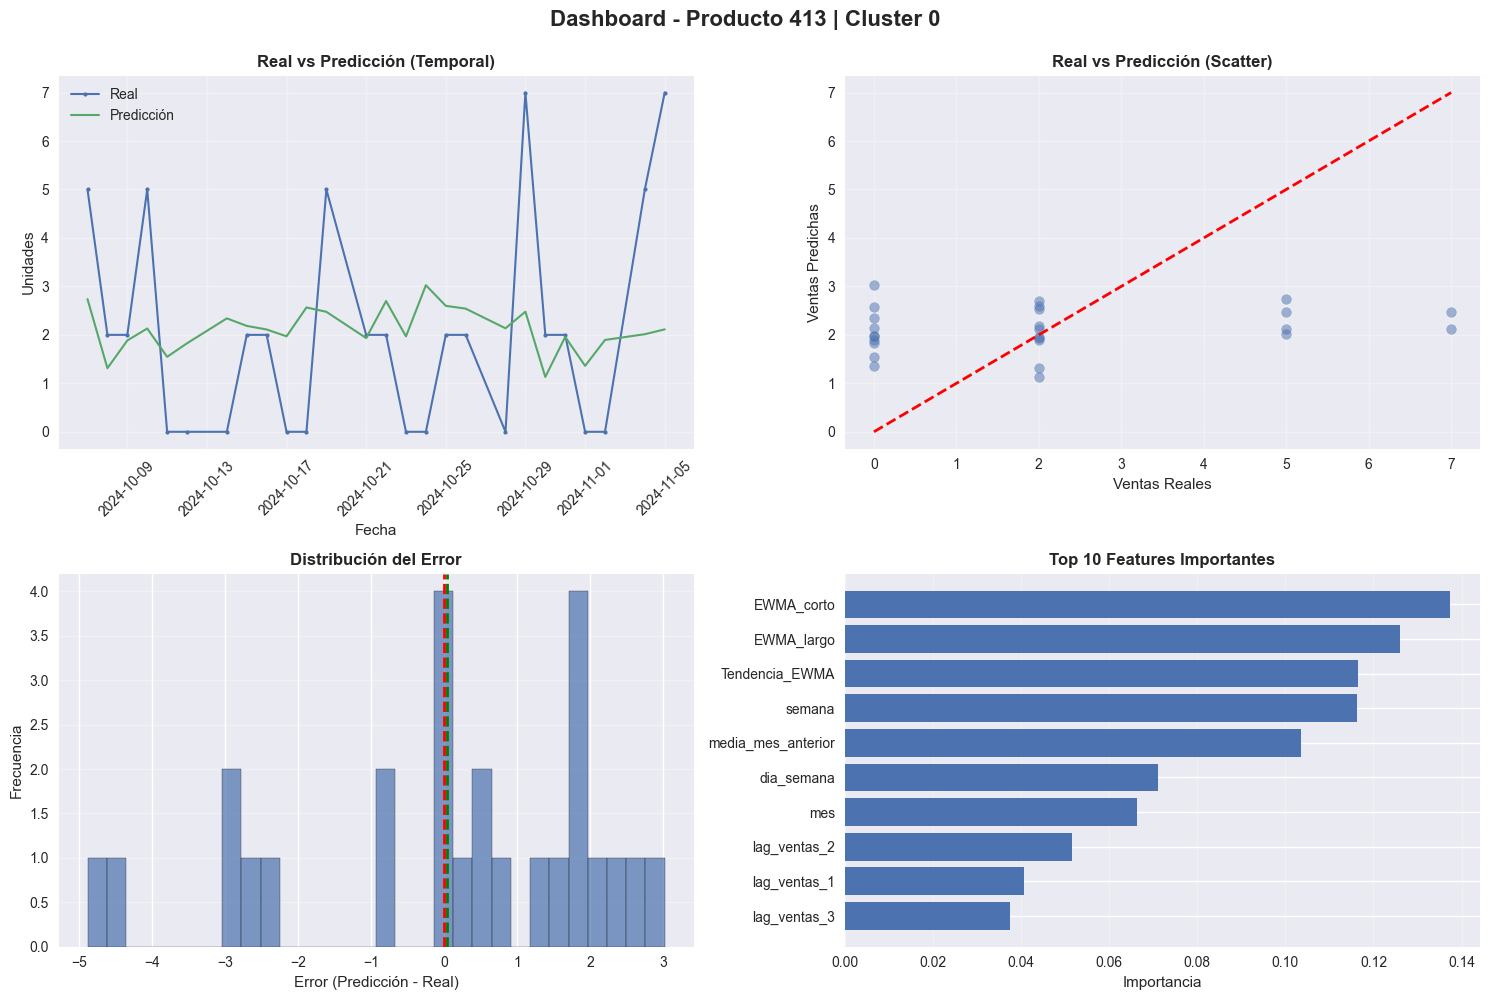


🔄 Entrenando modelo para Producto 294 (Cluster 0)...

📊 RESUMEN DE MÉTRICAS
           Algoritmo    MAE     MSE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
RF Producto 294 (C0) 2.5091 10.0226 3.1658 -0.2565     57.81     138.22 0.7294   135.91

🏆 Mejor modelo: RF Producto 294 (C0) (RMSE: 3.1658)

📊 RESUMEN DE MÉTRICAS
           Algoritmo    MAE     MSE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
RF Producto 294 (C0) 2.5091 10.0226 3.1658 -0.2565     57.81     138.22 0.7294   135.91

🏆 Mejor modelo: RF Producto 294 (C0) (RMSE: 3.1658)


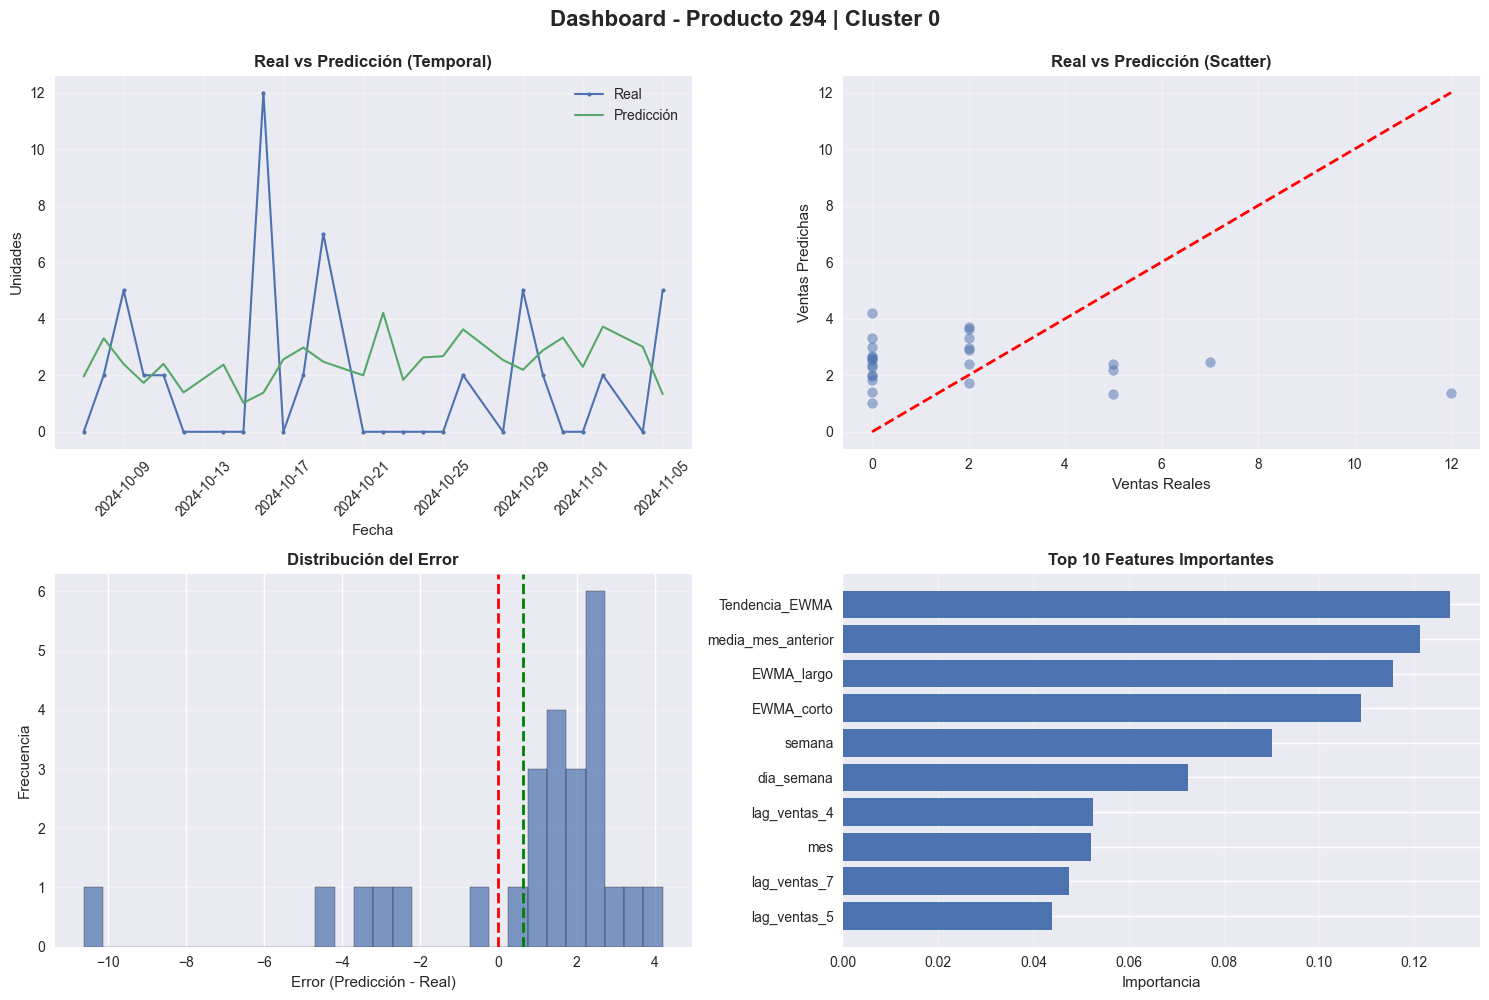


🎯 CLUSTER 1 - Top 2 productos

🔄 Entrenando modelo para Producto 144 (Cluster 1)...

📊 RESUMEN DE MÉTRICAS
           Algoritmo    MAE     MSE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
RF Producto 144 (C1) 4.3508 29.1592 5.3999 -0.1351     85.88      88.94 0.8071    76.95

🏆 Mejor modelo: RF Producto 144 (C1) (RMSE: 5.3999)

📊 RESUMEN DE MÉTRICAS
           Algoritmo    MAE     MSE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
RF Producto 144 (C1) 4.3508 29.1592 5.3999 -0.1351     85.88      88.94 0.8071    76.95

🏆 Mejor modelo: RF Producto 144 (C1) (RMSE: 5.3999)


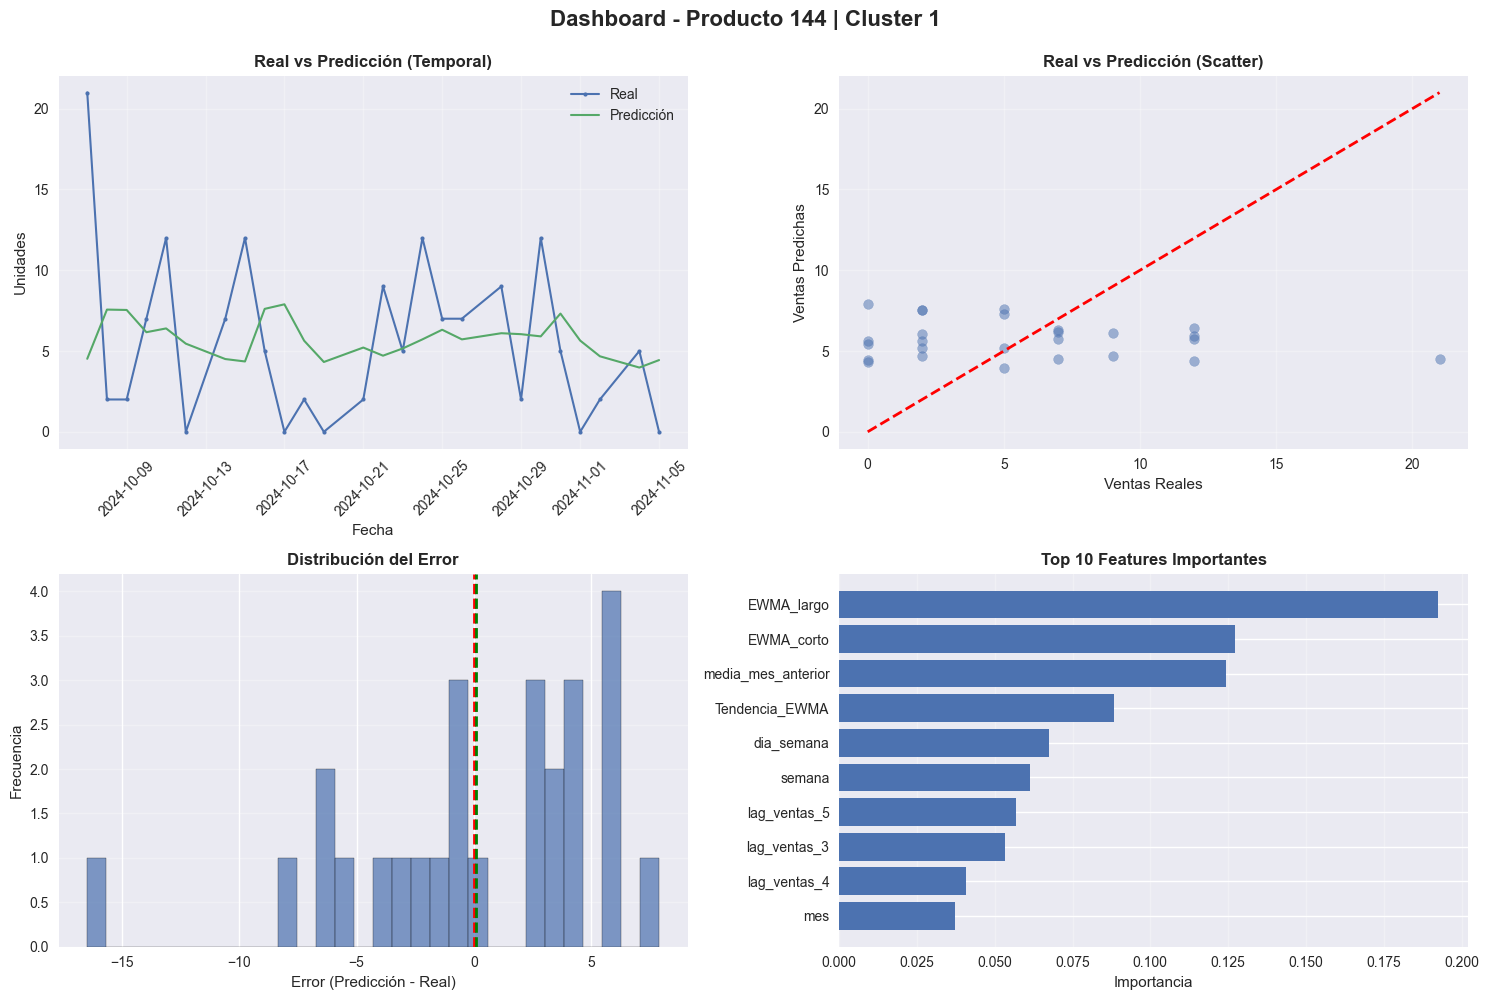


🔄 Entrenando modelo para Producto 41 (Cluster 1)...

📊 RESUMEN DE MÉTRICAS
           Algoritmo    MAE    MSE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 RF Producto 41 (C1) 3.6397 22.505 4.7439 -0.1037     58.42       66.4 0.8098    55.02

🏆 Mejor modelo: RF Producto 41 (C1) (RMSE: 4.7439)

📊 RESUMEN DE MÉTRICAS
           Algoritmo    MAE    MSE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 RF Producto 41 (C1) 3.6397 22.505 4.7439 -0.1037     58.42       66.4 0.8098    55.02

🏆 Mejor modelo: RF Producto 41 (C1) (RMSE: 4.7439)


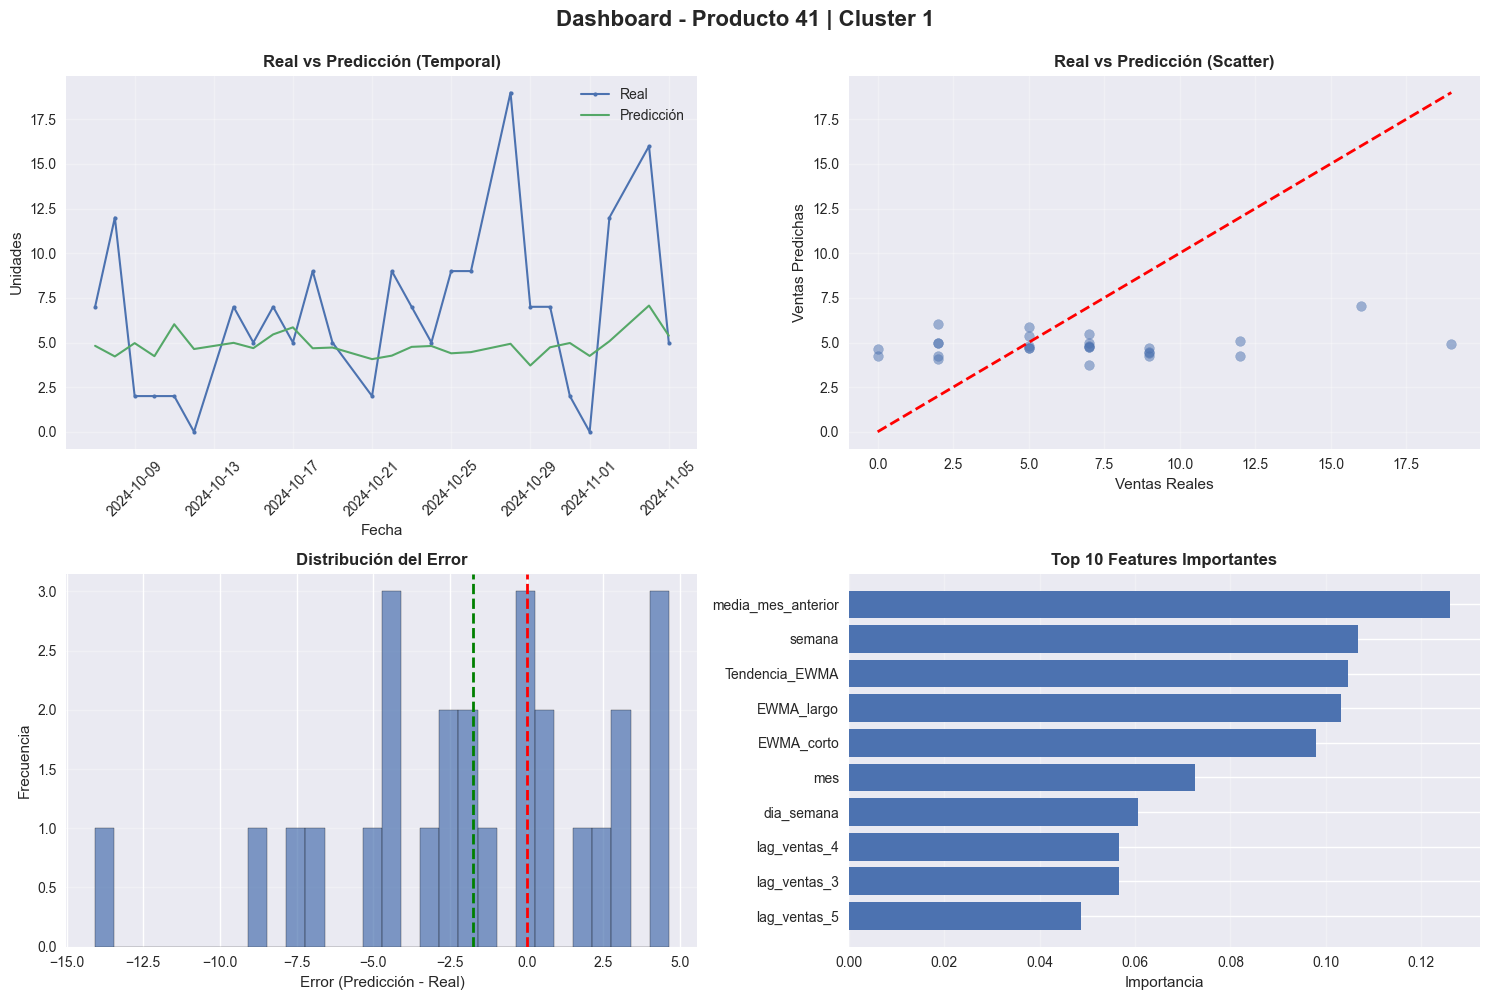


🎯 CLUSTER 2 - Top 2 productos

🔄 Entrenando modelo para Producto 1 (Cluster 2)...

📊 RESUMEN DE MÉTRICAS
           Algoritmo    MAE      MSE    RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
  RF Producto 1 (C2) 8.2132 133.6893 11.5624 -0.0775    118.39      72.73  0.728    69.56

🏆 Mejor modelo: RF Producto 1 (C2) (RMSE: 11.5624)

📊 RESUMEN DE MÉTRICAS
           Algoritmo    MAE      MSE    RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
  RF Producto 1 (C2) 8.2132 133.6893 11.5624 -0.0775    118.39      72.73  0.728    69.56

🏆 Mejor modelo: RF Producto 1 (C2) (RMSE: 11.5624)


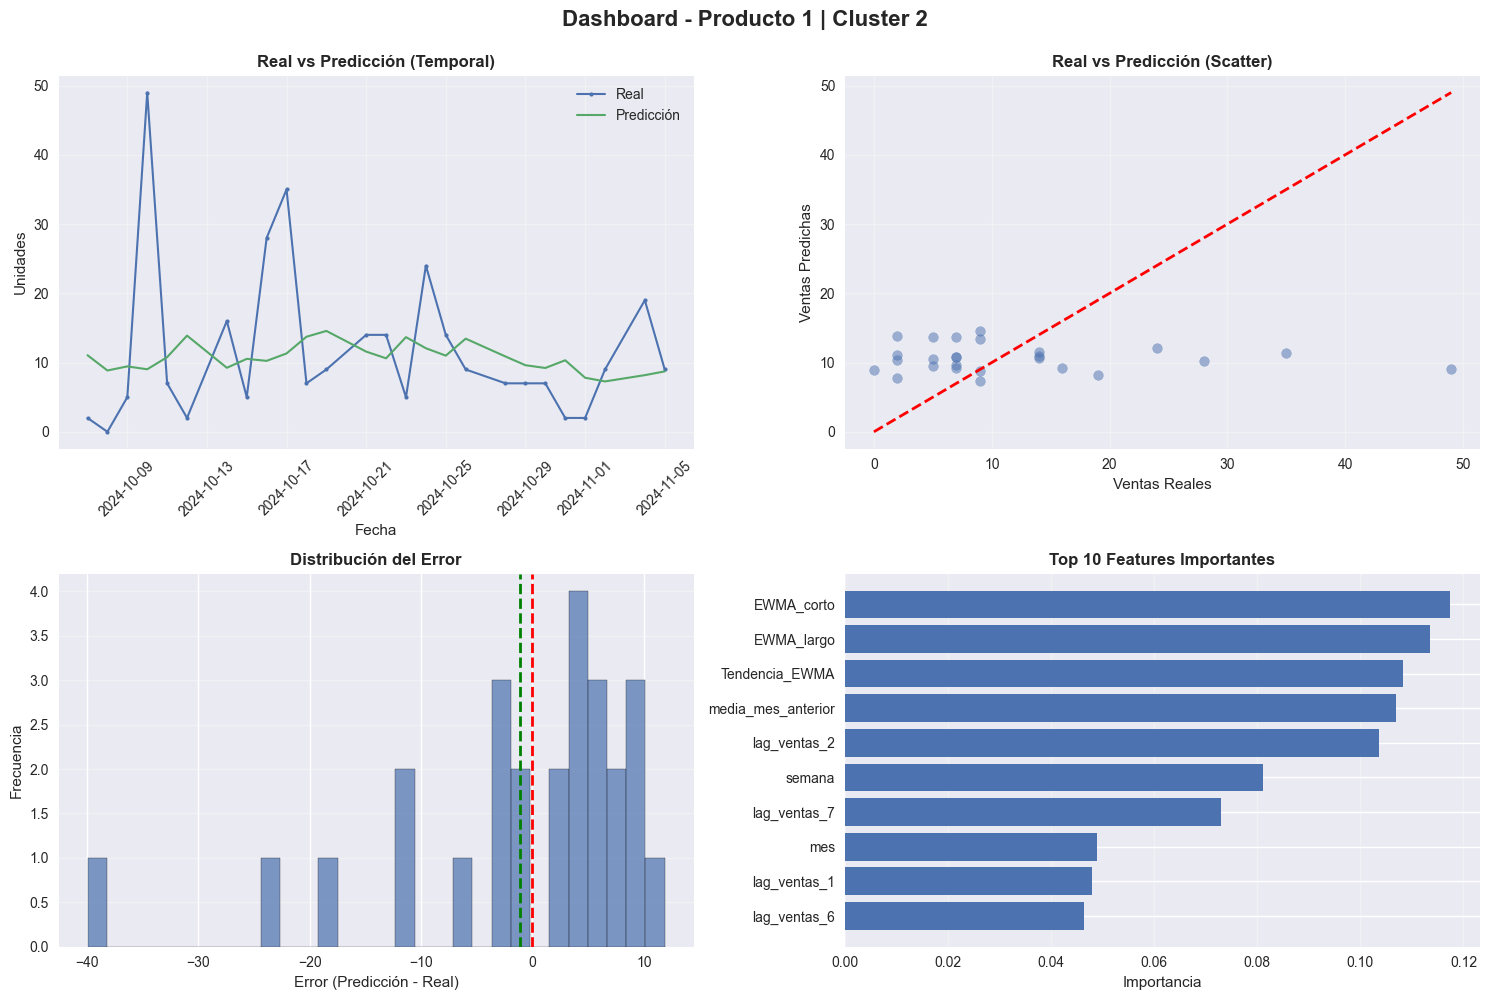


🔄 Entrenando modelo para Producto 2 (Cluster 2)...

📊 RESUMEN DE MÉTRICAS
           Algoritmo   MAE     MSE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
  RF Producto 2 (C2) 3.954 23.4725 4.8448 -0.1482     85.86      68.09 0.6732    62.69

🏆 Mejor modelo: RF Producto 2 (C2) (RMSE: 4.8448)

📊 RESUMEN DE MÉTRICAS
           Algoritmo   MAE     MSE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
  RF Producto 2 (C2) 3.954 23.4725 4.8448 -0.1482     85.86      68.09 0.6732    62.69

🏆 Mejor modelo: RF Producto 2 (C2) (RMSE: 4.8448)


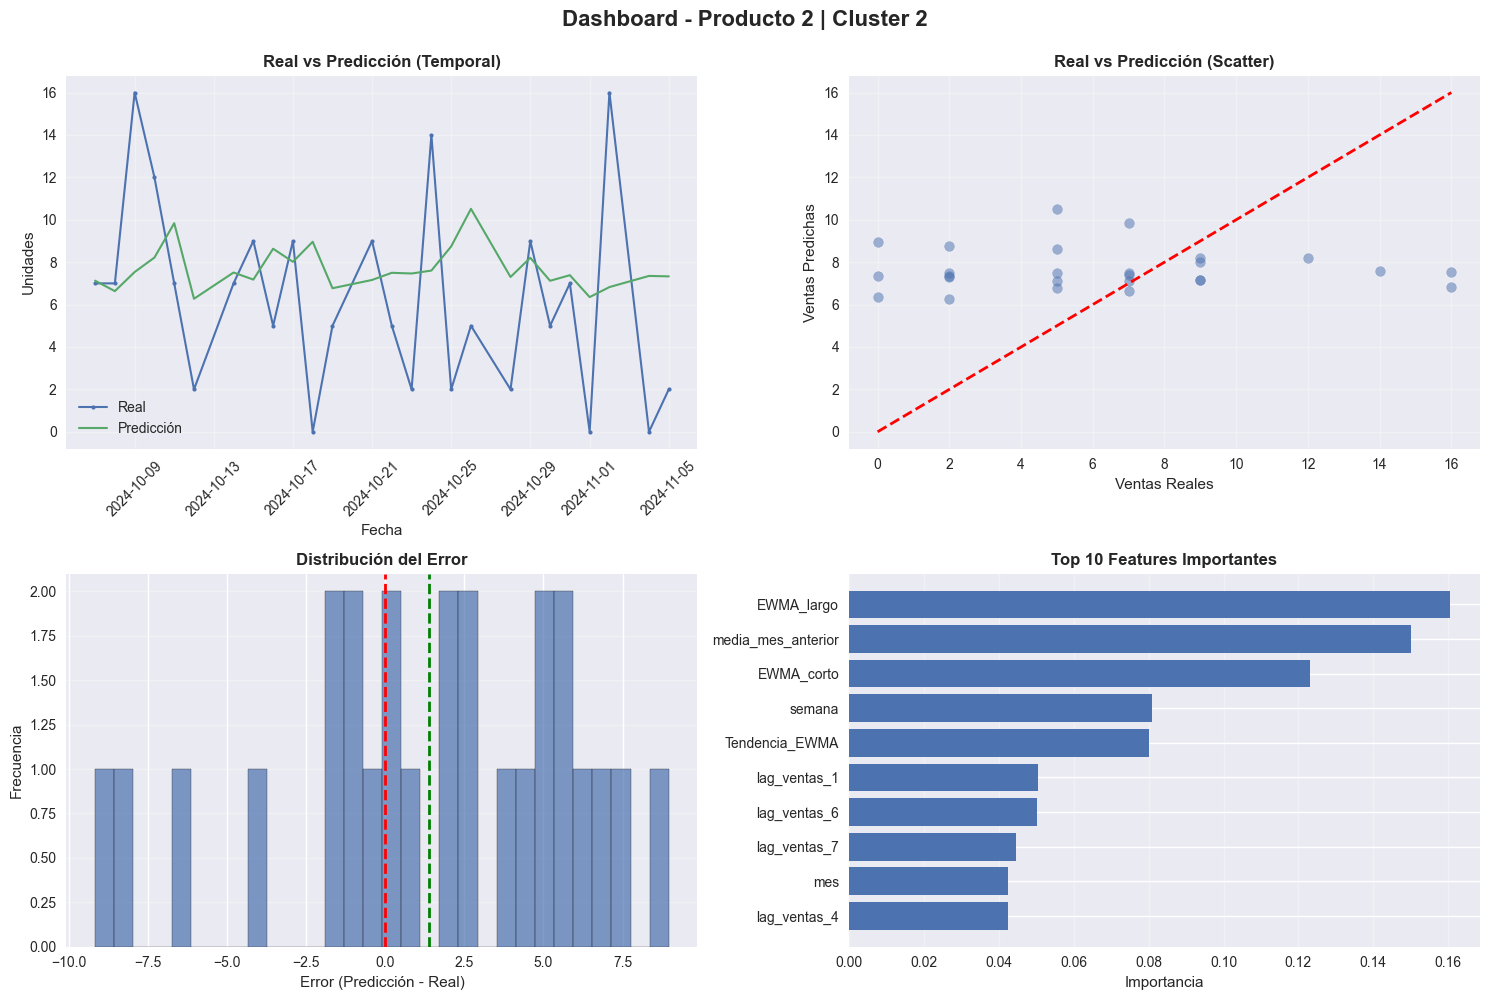


🎯 CLUSTER 3 - Top 2 productos

🔄 Entrenando modelo para Producto 257 (Cluster 3)...

📊 RESUMEN DE MÉTRICAS
           Algoritmo    MAE    MSE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
RF Producto 257 (C3) 0.8276 1.4712 1.2129 -0.1088     66.93     182.98 0.8253   165.52

🏆 Mejor modelo: RF Producto 257 (C3) (RMSE: 1.2129)

📊 RESUMEN DE MÉTRICAS
           Algoritmo    MAE    MSE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
RF Producto 257 (C3) 0.8276 1.4712 1.2129 -0.1088     66.93     182.98 0.8253   165.52

🏆 Mejor modelo: RF Producto 257 (C3) (RMSE: 1.2129)


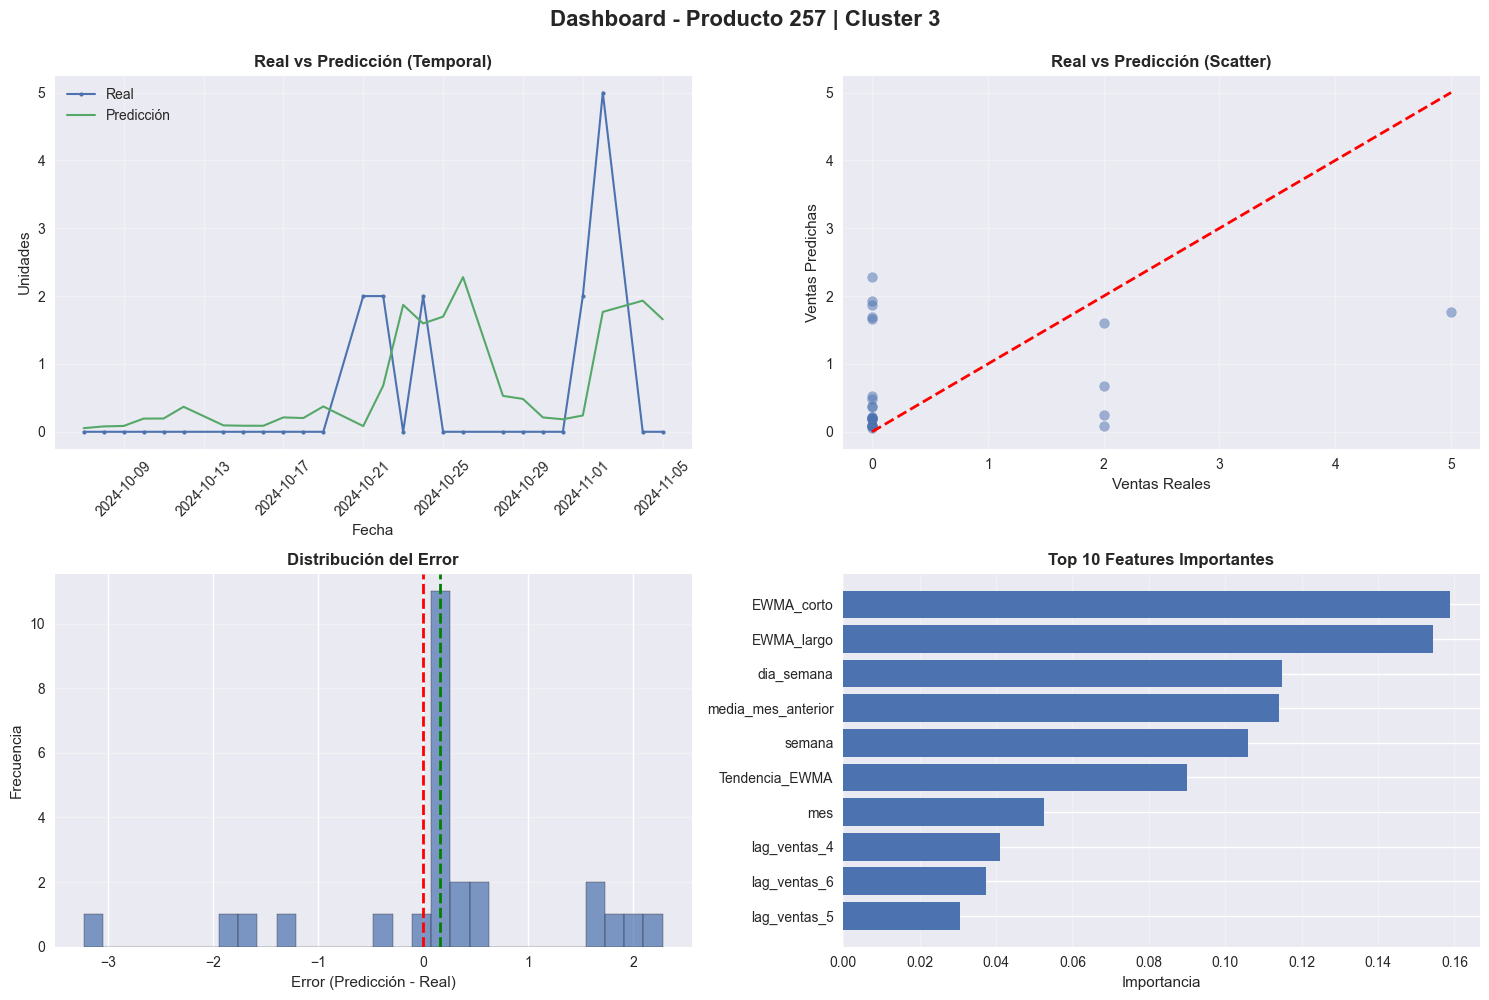


🔄 Entrenando modelo para Producto 314 (Cluster 3)...

📊 RESUMEN DE MÉTRICAS
           Algoritmo   MAE    MSE   RMSE  R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
RF Producto 314 (C3) 0.371 0.1417 0.3764 0.0       NaN      200.0    NaN      NaN

🏆 Mejor modelo: RF Producto 314 (C3) (RMSE: 0.3764)

📊 RESUMEN DE MÉTRICAS
           Algoritmo   MAE    MSE   RMSE  R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
RF Producto 314 (C3) 0.371 0.1417 0.3764 0.0       NaN      200.0    NaN      NaN

🏆 Mejor modelo: RF Producto 314 (C3) (RMSE: 0.3764)


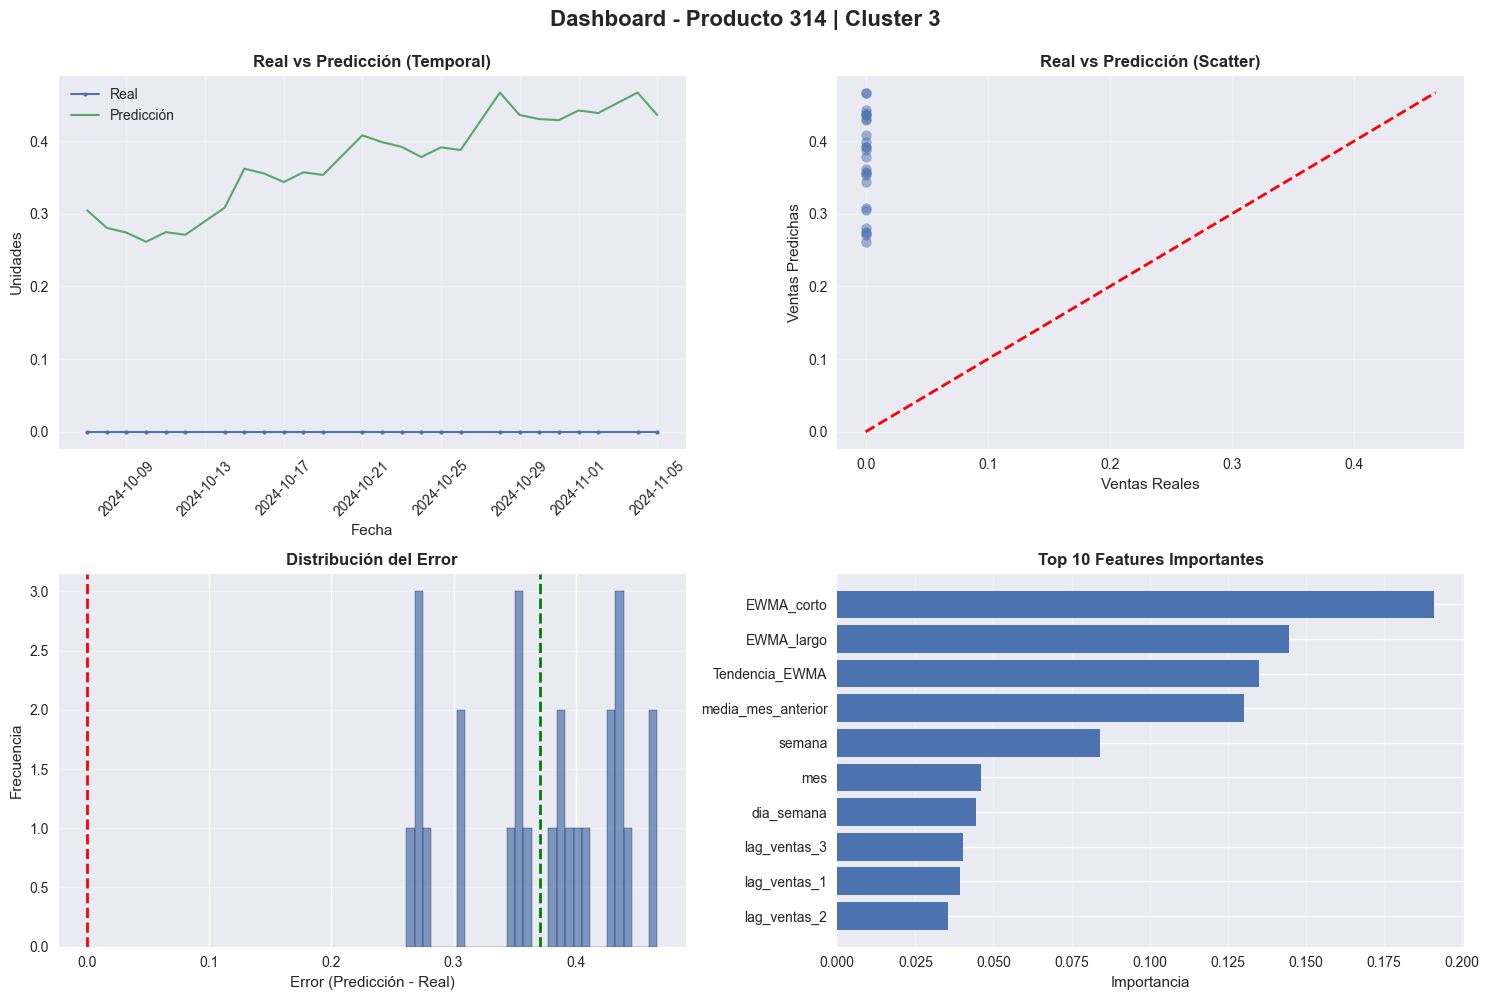


✅ Modelos por producto completados: 8 modelos entrenados


In [ ]:
# ============================================================================
# 3. MODELOS POR PRODUCTO TOP (2 POR CLUSTER)
# ============================================================================

print("\n" + "="*100)
print("📍 MODELO 3: RANDOM FOREST POR PRODUCTO TOP (2 POR CLUSTER)")
print("="*100)

modelos_producto = {}

# Obtener los 2 productos top por cluster
productos_top_cluster = obtener_top_productos_por_cluster(
    df=df_train,
    col_ventas='udsVenta',
    col_cluster='Cluster',
    col_producto='producto',
    n_productos=2
)

# Iterar por cada cluster y sus productos top
for cluster, productos in productos_top_cluster.items():
    print(f"\n{'='*100}")
    print(f"🎯 CLUSTER {cluster} - Top {len(productos)} productos")
    print(f"{'='*100}")
    
    for producto in productos:
        print(f"\n🔄 Entrenando modelo para Producto {producto} (Cluster {cluster})...")
        
        # Filtrar datos por cluster y producto
        train_prod = df_train[(df_train['Cluster'] == cluster) & (df_train['producto'] == producto)]
        test_prod = df_test[(df_test['Cluster'] == cluster) & (df_test['producto'] == producto)].dropna()
        
        # Preparar características y target
        X_train_p = train_prod[FEATURES]
        y_train_p = train_prod[TARGET]
        X_test_p = test_prod[FEATURES]
        y_test_p = test_prod[TARGET]
        
        # Entrenar modelo con los mejores hiperparámetros de Optuna
        rf_producto = RandomForestRegressor(
            **study_rf.best_params,
            random_state=42,
            n_jobs=-1
        )
        
        rf_producto.fit(X_train_p, y_train_p)
        y_pred_p = rf_producto.predict(X_test_p)
        
        # Guardar modelo
        modelos_producto[f"C{cluster}_P{producto}"] = rf_producto
        
        # Calcular métricas y GUARDAR
        metricas_producto = calcular_metricas(y_test_p, y_pred_p, f"RF Producto {producto} (C{cluster})")
        todas_metricas.append(metricas_producto)
        resumen_metricas([metricas_producto])
                
        # Preparar datos para visualización
        test_prod_pred = test_prod.copy()
        test_prod_pred['prediccion'] = y_pred_p
        test_prod_pred['error'] = y_pred_p - test_prod_pred[TARGET]
        test_prod_pred['error_abs'] = np.abs(test_prod_pred['error'])
        test_prod_pred['error_pct'] = (test_prod_pred['error_abs'] / (test_prod_pred[TARGET] + 1e-10)) * 100
        test_prod_pred = test_prod_pred.sort_values('idSecuencia')
        
        # Dashboard de predicción
        dashboard_prediccion(
            df=test_prod_pred,
            col_fecha='idSecuencia',
            col_real=TARGET,
            col_pred='prediccion',
            modelo=rf_producto,
            feature_names=FEATURES,
            titulo_principal=f'Dashboard - Producto {producto} | Cluster {cluster}',
            figsize=(10, 7)
            )

print(f"\n{'='*100}")
print(f"✅ Modelos por producto completados: {len(modelos_producto)} modelos entrenados")
print(f"{'='*100}")


# Resumen final


🏆 RESUMEN FINAL - COMPARACIÓN DE TODOS LOS MODELOS

📊 Resumen de todas las métricas:

📊 RESUMEN DE MÉTRICAS
                       Algoritmo    MAE      MSE    RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
RF Global Cluster 3 Producto 314 0.3353   0.1239  0.3520  0.0000       NaN     200.00    NaN      NaN
            RF Producto 314 (C3) 0.3710   0.1417  0.3764  0.0000       NaN     200.00    NaN      NaN
       RF Cluster 3 Producto 314 0.4293   0.1923  0.4385  0.0000       NaN     200.00    NaN      NaN
RF Global Cluster 3 Producto 257 0.8588   1.3869  1.1776 -0.0452     73.80     184.80 0.8013   171.75
       RF Cluster 3 Producto 257 0.8836   1.4403  1.2001 -0.0855     74.14     184.84 0.8166   176.72
            RF Producto 257 (C3) 0.8276   1.4712  1.2129 -0.1088     66.93     182.98 0.8253   165.52
                    RF Cluster 3 1.0949   2.9448  1.7160  0.0133     54.26     168.51 0.7701   134.82
             RF Global Cluster 3 1.0967   2.9465  1.7165  0.0127     54.09 

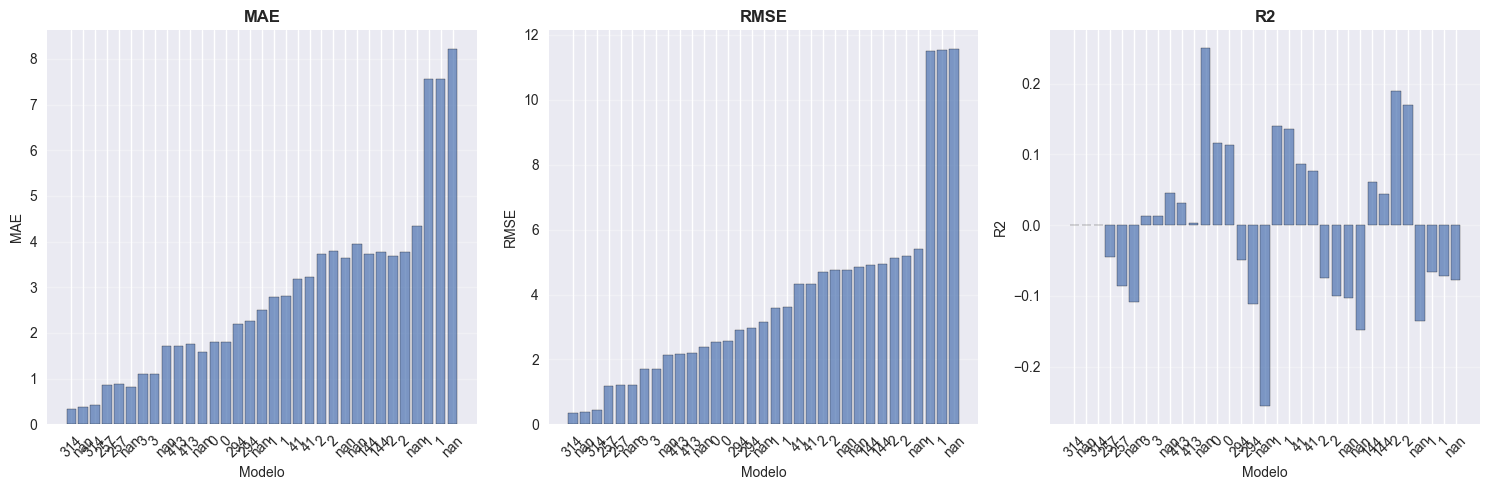


📊 ANÁLISIS POR CATEGORÍAS DE MODELOS

🌍 MODELOS GLOBALES:
                       Algoritmo    MAE    RMSE      R2
RF Global Cluster 3 Producto 314 0.3353  0.3520  0.0000
RF Global Cluster 3 Producto 257 0.8588  1.1776 -0.0452
             RF Global Cluster 3 1.0967  1.7165  0.0127
RF Global Cluster 0 Producto 413 1.7258  2.1649  0.0317
                       RF Global 1.5844  2.3970  0.2502
             RF Global Cluster 0 1.8104  2.5508  0.1161
RF Global Cluster 0 Producto 294 2.2015  2.8929 -0.0492
             RF Global Cluster 1 2.7916  3.5960  0.1399
 RF Global Cluster 1 Producto 41 3.1765  4.3152  0.0868
  RF Global Cluster 2 Producto 2 3.7265  4.6885 -0.0753
RF Global Cluster 1 Producto 144 3.7244  4.9105  0.0613
             RF Global Cluster 2 3.6940  5.1201  0.1899
  RF Global Cluster 2 Producto 1 7.5692 11.5304 -0.0715

   Promedio RMSE: 3.65

🎯 MODELOS POR CLUSTER:
                       Algoritmo    MAE    RMSE      R2
RF Global Cluster 3 Producto 314 0.3353  0.3520  0.00

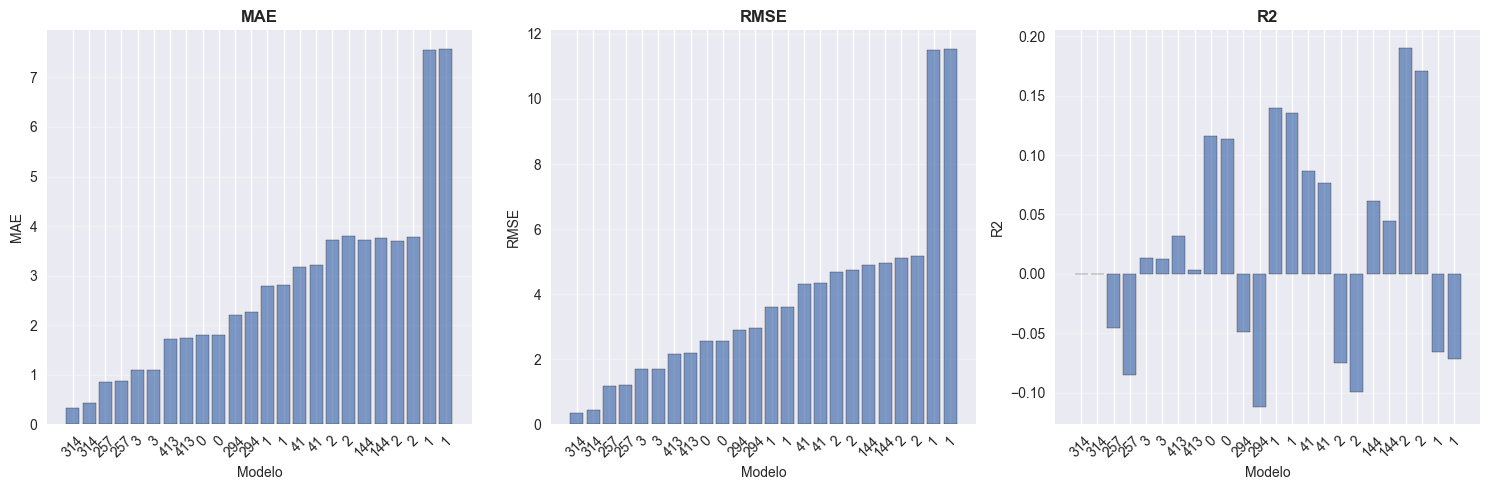


📊 Comparación entre productos:


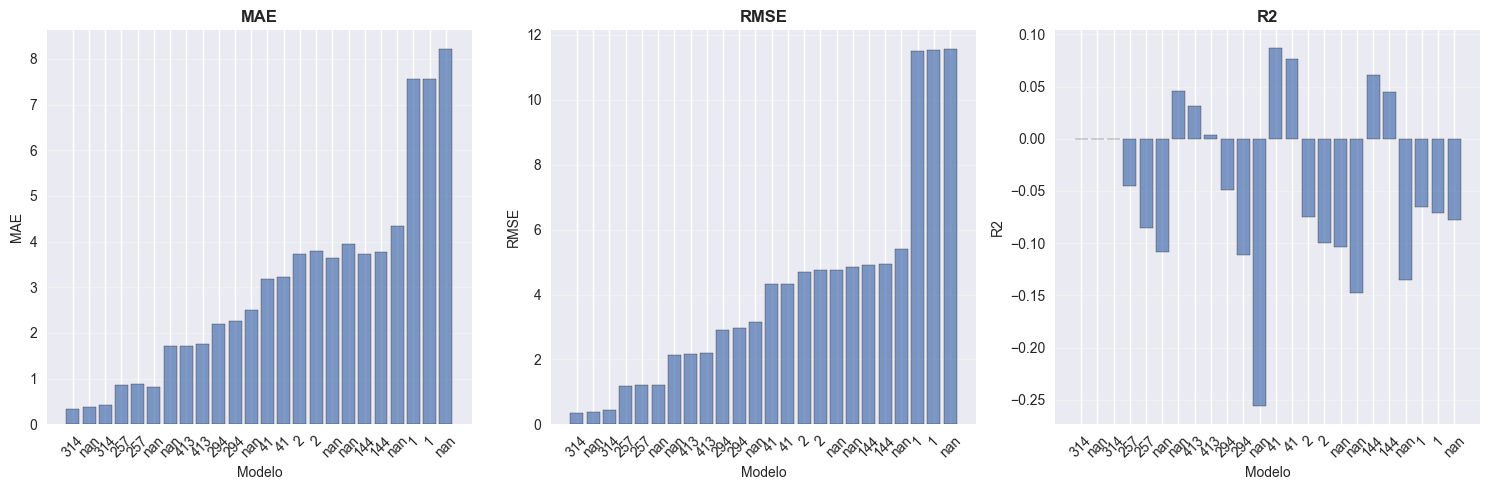


✅ ANÁLISIS COMPLETO FINALIZADO

📊 Total de modelos evaluados: 33
   - Modelos globales: 13
   - Modelos por cluster: 24
   - Modelos por producto: 24


In [14]:

# ============================================================================
# 4. RESUMEN FINAL DE TODOS LOS MODELOS
# ============================================================================

print("\n" + "="*100)
print("🏆 RESUMEN FINAL - COMPARACIÓN DE TODOS LOS MODELOS")
print("="*100)

if todas_metricas:
    # Mostrar tabla completa de métricas
    print("\n📊 Resumen de todas las métricas:")
    resumen_metricas(todas_metricas)
    
    # Comparar métricas
    df_comparacion_final = comparar_metricas(todas_metricas, ordenar_por='RMSE')
    
    print("\n" + "="*100)
    print("📈 RANKING DE MODELOS POR RMSE")
    print("="*100)
    print(df_comparacion_final[['Algoritmo', 'MAE', 'RMSE', 'R2', 'MAPE (%)']].to_string(index=False))
    
    # Gráfico comparativo de TODOS los modelos
    print("\n📊 Generando gráficos comparativos...")
    grafico_comparacion_metricas(df_comparacion_final, metricas=['MAE', 'RMSE', 'R2'])
    
    # Análisis por categorías
    print("\n" + "="*100)
    print("📊 ANÁLISIS POR CATEGORÍAS DE MODELOS")
    print("="*100)
    
    # Separar por tipo de modelo
    df_global = df_comparacion_final[df_comparacion_final['Algoritmo'].str.contains('Global')]
    df_clusters = df_comparacion_final[df_comparacion_final['Algoritmo'].str.contains('Cluster')]
    df_productos = df_comparacion_final[df_comparacion_final['Algoritmo'].str.contains('Producto')]
    
    print("\n🌍 MODELOS GLOBALES:")
    if len(df_global) > 0:
        print(df_global[['Algoritmo', 'MAE', 'RMSE', 'R2']].to_string(index=False))
        print(f"\n   Promedio RMSE: {df_global['RMSE'].mean():.2f}")
    
    print("\n🎯 MODELOS POR CLUSTER:")
    if len(df_clusters) > 0:
        print(df_clusters[['Algoritmo', 'MAE', 'RMSE', 'R2']].to_string(index=False))
        print(f"\n   Promedio RMSE: {df_clusters['RMSE'].mean():.2f}")
        print(f"   Mejor cluster: {df_clusters.iloc[0]['Algoritmo']} (RMSE: {df_clusters.iloc[0]['RMSE']:.2f})")
        print(f"   Peor cluster: {df_clusters.iloc[-1]['Algoritmo']} (RMSE: {df_clusters.iloc[-1]['RMSE']:.2f})")
    
    print("\n🛒 MODELOS POR PRODUCTO:")
    if len(df_productos) > 0:
        print(df_productos[['Algoritmo', 'MAE', 'RMSE', 'R2']].to_string(index=False))
        print(f"\n   Promedio RMSE: {df_productos['RMSE'].mean():.2f}")
        print(f"   Mejor producto: {df_productos.iloc[0]['Algoritmo']} (RMSE: {df_productos.iloc[0]['RMSE']:.2f})")
        print(f"   Peor producto: {df_productos.iloc[-1]['Algoritmo']} (RMSE: {df_productos.iloc[-1]['RMSE']:.2f})")
    
    # Mejor modelo general
    print("\n" + "="*100)
    print("🥇 MEJOR MODELO GENERAL")
    print("="*100)
    mejor_idx = df_comparacion_final['RMSE'].idxmin()
    mejor_modelo = df_comparacion_final.loc[mejor_idx]
    
    print(f"\n🏆 {mejor_modelo['Algoritmo']}")
    print(f"   MAE:        {mejor_modelo['MAE']:.2f}")
    print(f"   RMSE:       {mejor_modelo['RMSE']:.2f}")
    print(f"   R²:         {mejor_modelo['R2']:.4f}")
    print(f"   MAPE:       {mejor_modelo['MAPE (%)']:.2f}%")
    print(f"   SMAPE:      {mejor_modelo['SMAPE (%)']:.2f}%")
    
    # Gráficos comparativos por categoría
    if len(df_clusters) > 1:
        print("\n📊 Comparación entre clusters:")
        grafico_comparacion_metricas(df_clusters, metricas=['MAE', 'RMSE', 'R2'])
    
    if len(df_productos) > 1:
        print("\n📊 Comparación entre productos:")
        grafico_comparacion_metricas(df_productos, metricas=['MAE', 'RMSE', 'R2'])
    
else:
    print("\n⚠️  No se generaron métricas para ningún modelo")

print("\n" + "="*100)
print("✅ ANÁLISIS COMPLETO FINALIZADO")
print("="*100)
print(f"\n📊 Total de modelos evaluados: {len(todas_metricas)}")
print(f"   - Modelos globales: {len([m for m in todas_metricas if 'Global' in m['Algoritmo']])}")
print(f"   - Modelos por cluster: {len([m for m in todas_metricas if 'Cluster' in m['Algoritmo']])}")
print(f"   - Modelos por producto: {len([m for m in todas_metricas if 'Producto' in m['Algoritmo']])}")

# Salvar resultados

In [15]:
# salvar resultados en fichero
df_resultados = pd.DataFrame(todas_metricas)
df_resultados.to_csv('datos/resultados_metricas_rf.csv', index=False)